# 매크로 팩터 → 대체투자 분기수익률 Nowcast

매크로 팩터(growth / term / inflation / credit, `macro_factor` 저장소, **읽기 전용**)로 Burgiss·MSCI·G-L·HFRI 등 대체투자 지수의
분기 수익률을 nowcast 한다. 두 모델을 만들고 확장창 OOS 백테스트로 비교한 뒤, 아직 발표되지 않은 분기(완전 분기 + 진행 중 QTD 분기)의 값을 낸다.

| 모델 | 식 | 성격 |
|---|---|---|
| **A: Ridge 분포시차** | y_q = c + Σ_{l=0..4} β_l'F_{q−l} + φ y_{q−1} + e | reduced form. 보고 지연·스무딩을 lag 계수가 흡수 |
| **B: 월간 상태공간(칼만)** | r*_m = α + β'F_m + η_m ; y_q = θ y_{q−1} + (1−θ) Σ_{m∈q} r*_m | structural. Geltner 스무딩 θ, 잠재 월간 수익률, 부분 분기 자연 처리 |
| Ensemble | (A + B) / 2 | |
| 벤치마크 | 확장창 평균 · AR(1) · OLS (y ~ 1 + y_{q−1} + F_q) | OLS 는 B 의 완전분기 점예측과 사실상 같은 식 |

산출물은 `scripts/run_backtest.py` → `scripts/run_nowcast.py` → `scripts/make_report.py` 로 재현되며, 이 노트북은 그 결과(`data/processed/*.csv`)를 읽어 보여준다.


In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src.altnow.config import load_config, resolve
from src.altnow.data import load_alt_returns, load_factors_daily, to_quarterly, period_coverage, quarter_status
from src.altnow import plots
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
cfg = load_config(ROOT / "config/nowcast.yaml")
PROC, FIGS = resolve(cfg["paths"]["processed"]), resolve(cfg["paths"]["reports"]) / "figs"
alt = load_alt_returns(cfg); f = load_factors_daily(cfg)
order = list(alt.meta.index); factors = cfg["factors"]
MODELS = ["mean", "ar1", "ols", "ridge_dl", "ss_kalman", "ensemble"]
def pct(x, d=2): return "" if pd.isna(x) else f"{100*x:.{d}f}%"
def qlabel(q): q = pd.Timestamp(q); return f"{q.year}Q{(q.month-1)//3+1}"
print("alt returns", alt.series.shape, alt.series.index[0].date(), "~", alt.series.index[-1].date())
print("factors     ", f.shape, f.index[0].date(), "~", f.index[-1].date())

alt returns (105, 15) 2000-03-31 ~ 2026-03-31
factors      (5195, 4) 2006-02-01 ~ 2026-09-15


## 1. 데이터

엑셀 21개 라벨 중 원지수가 같은 것은 한 시리즈로 추정한다 (Growth = VC, FoF = GP-Stake, 국내부동산 = Core RE Equity, 인프라 4종 = Burgiss Infra Core).

In [2]:
m = alt.meta.copy(); m["labels"] = m["labels"].map(lambda l: ", ".join(l))
m["first"] = [alt.series[c].first_valid_index().date() for c in m.index]
m["last"] = [alt.series[c].last_valid_index().date() for c in m.index]
m["n"] = [int(alt.series[c].count()) for c in m.index]
m

,index,group,labels,first,last,n
code,,,,,,
buyout,Burgiss Buyout Index,PE,Buyout,2000-03-31,2026-03-31,105
vc,Burgiss Venture Capital Index,PE,"Growth, Venture Capital",2000-03-31,2026-03-31,105
fof_secondary,Burgiss FoF Secondary Equity Index,PE,"Fund of Fund, GP-Stake / Continuation Vehicle",2002-03-31,2026-03-31,97
fof_primary,Burgiss FoF Primary Equity Index,PE,Long-term Core,2000-03-31,2026-03-31,105
senior_loan,Burgiss Senior Loan Index,PE,Senior Credit,2010-06-30,2026-03-31,64
mezzanine,Burgiss Mezzanine Index,PE,Junior Credit,2000-03-31,2026-03-31,105
apac_equity,Burgiss Equity Index (Asia & Pacific),PE,국내 사모투자,2000-03-31,2026-03-31,105
hfri_fof_cons,HFRI FoF: Conservative Index,HF,Hedge Fund,2000-03-31,2026-03-31,105
msci_gpfi,MSCI Global Property Fund Index,RE,"Core RE Equity, 국내 부동산",2008-03-31,2024-12-31,68


In [3]:
fq = to_quarterly(f); cov = period_coverage(f, "QE")
st = quarter_status(f)
display(Markdown(f"팩터 분기 복리수익률 (마지막 5분기). 진행 중 분기 **{qlabel(st['quarter_end'])}** 은 QTD (경과 영업일 {st['n_days']}), 완전 분기 아님."))
fq.tail(5).assign(partial=cov["partial"].reindex(fq.tail(5).index)).style.format({c: "{:.2%}" for c in factors})

팩터 분기 복리수익률 (마지막 5분기). 진행 중 분기 **2026Q3** 은 QTD (경과 영업일 55), 완전 분기 아님.

,growth,term,inflation,credit,partial
date,,,,,
2025-09-30 00:00:00,7.62%,1.76%,0.47%,1.16%,False
2025-12-31 00:00:00,3.29%,1.12%,-0.90%,0.27%,False
2026-03-31 00:00:00,-3.20%,-0.28%,0.50%,-0.48%,False
2026-06-30 00:00:00,14.93%,0.13%,0.78%,1.19%,False
2026-09-30 00:00:00,1.07%,-2.93%,1.03%,-0.03%,True


## 2. 백테스트 — 확장창 pseudo-real-time OOS

분기 q 예측에 쓰는 정보: 팩터는 q 분기말까지, 보고 수익률은 q−1 까지. 매 분기 모든 모델 재추정. 벤치마크는 확장창 평균, AR(1), 동분기 OLS.

> 의사 실시간 주의: 최종 빈티지 사용, y_{q−1} 을 q 분기말에 안다고 가정. 실전 정확도는 이보다 낮다.

In [4]:
summary = pd.read_csv(PROC / "backtest_summary.csv", index_col=[0, 1])
preds = {c: pd.read_csv(PROC / f"backtest_preds_{c}.csv", index_col=0, parse_dates=True) for c in order if (PROC / f"backtest_preds_{c}.csv").exists()}
tab = summary["rmse"].unstack("model")[MODELS].loc[order]
tab["r2_oos_ens"] = summary.xs("ensemble", level="model")["r2_oos_vs_mean"].loc[order]
tab["hit_ens"] = summary.xs("ensemble", level="model")["hit"].loc[order]
tab["dm_p_ens_vs_ar1"] = summary.xs("ensemble", level="model")["dm_p"].loc[order]
tab["n"] = summary.xs("ensemble", level="model")["n"].loc[order].astype(int)
tab.style.format({c: "{:.2%}" for c in MODELS} | {"r2_oos_ens": "{:.2f}", "hit_ens": "{:.2f}", "dm_p_ens_vs_ar1": "{:.3f}"}).set_caption("OOS RMSE (모델별) · Ensemble 의 R²_OOS(대 평균)·적중률·DM p(대 AR1)")

model,mean,ar1,ols,ridge_dl,ss_kalman,ensemble,r2_oos_ens,hit_ens,dm_p_ens_vs_ar1,n
code,,,,,,,,,,
buyout,3.79%,3.72%,2.19%,2.34%,2.19%,2.13%,0.68,0.95,0.020,57
vc,7.09%,5.47%,4.70%,5.23%,4.69%,4.88%,0.53,0.88,0.057,57
fof_secondary,4.03%,3.65%,3.20%,3.42%,3.16%,3.14%,0.39,0.88,0.079,57
fof_primary,4.14%,3.27%,2.38%,2.69%,2.39%,2.43%,0.65,0.89,0.017,57
senior_loan,1.75%,1.77%,1.88%,1.49%,1.83%,1.51%,0.26,0.84,0.383,44
mezzanine,3.39%,3.52%,1.94%,2.03%,1.90%,1.74%,0.74,0.91,0.122,57
apac_equity,4.00%,4.16%,3.17%,3.33%,3.16%,3.13%,0.39,0.88,0.039,57
hfri_fof_cons,1.92%,2.03%,1.00%,0.98%,1.00%,0.92%,0.77,0.88,0.027,57
msci_gpfi,2.60%,2.20%,2.36%,2.21%,2.36%,2.17%,0.30,0.75,0.926,48


In [5]:
grp = summary.reset_index().merge(alt.meta[["group"]], left_on="code", right_index=True)
g = grp.groupby(["group", "model"])["r2_oos_vs_mean"].mean().unstack("model")[MODELS[1:]]
g.round(2).style.set_caption("그룹 평균 R²_OOS (대 확장창 평균)")

model,ar1,ols,ridge_dl,ss_kalman,ensemble
group,,,,,
HF,-0.120000,0.730000,0.740000,0.730000,0.770000
INFRA,-0.060000,0.570000,0.480000,0.580000,0.590000
PE,0.120000,0.450000,0.450000,0.460000,0.520000
RE,0.090000,0.140000,0.090000,0.130000,0.270000


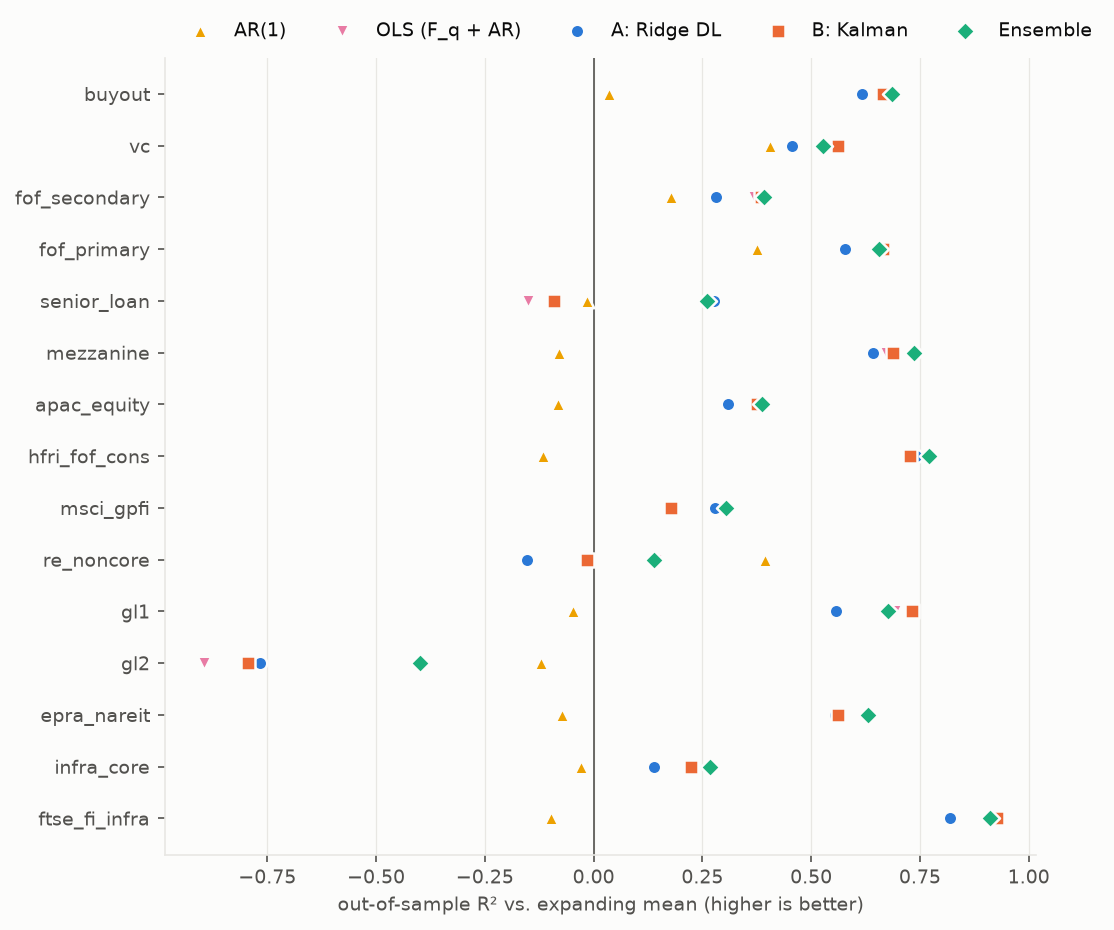

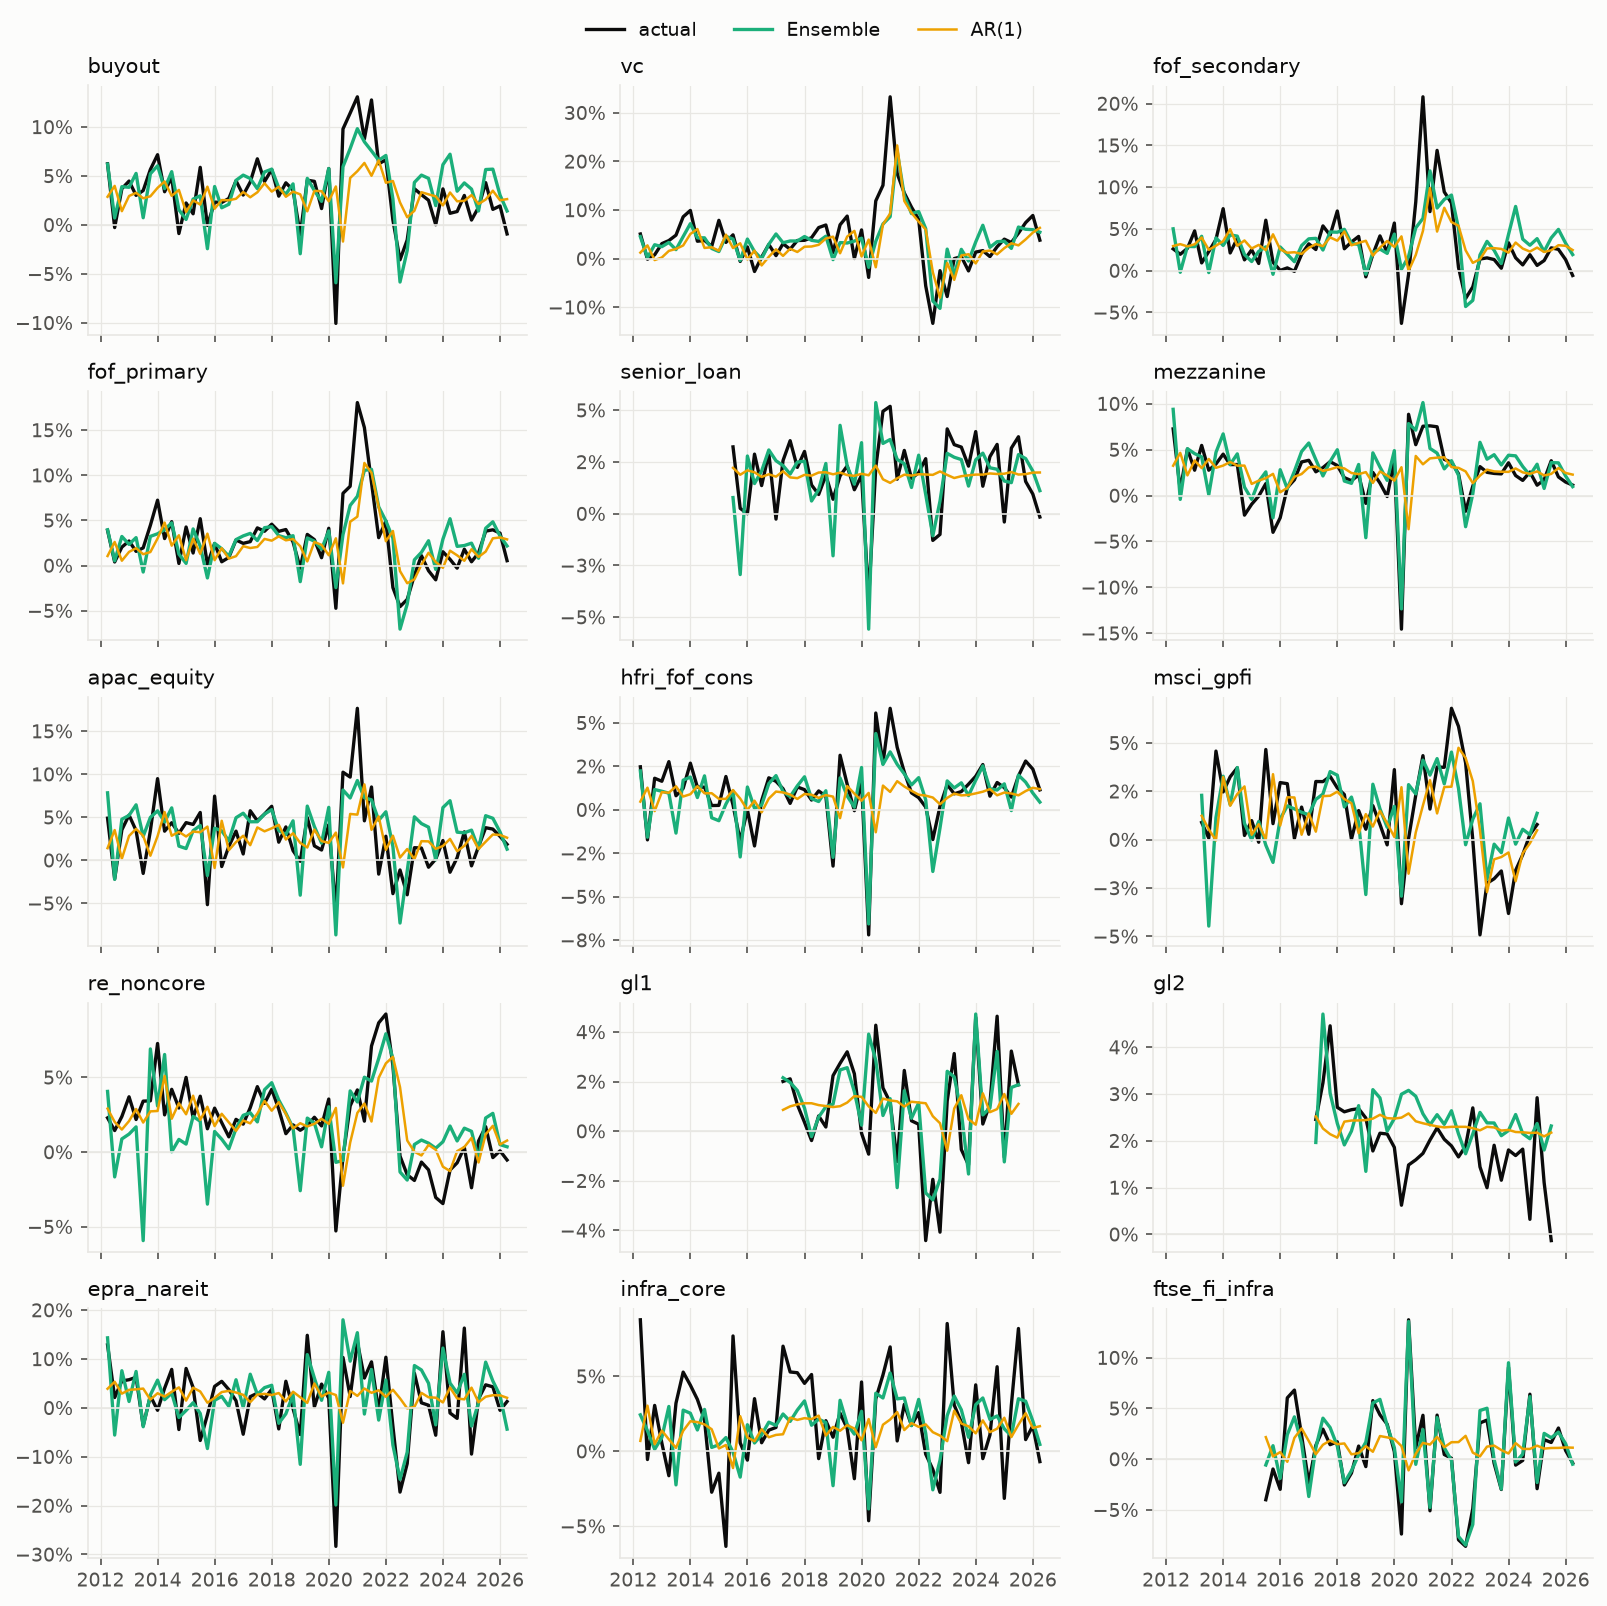

In [6]:
plots.plot_oos_r2(summary, order, FIGS / "oos_r2.png"); display(Image(FIGS / "oos_r2.png"))
plots.plot_oos_paths(preds, [c for c in order if c in preds], FIGS / "oos_paths.png"); display(Image(FIGS / "oos_paths.png"))

### 모델 B 와 OLS 가 왜 거의 같은가

관측오차를 0 으로 두고 완전 분기만 보면 B 의 점예측은 y_q = θ y_{q−1} + (1−θ)(3α + β'ΣF_m) 이고, 이는 y ~ 1 + y_{q−1} + F_q 의 OLS 와 같은 식(로그수익률, 계수 재매개화)이다.
그래서 완전 분기 OOS RMSE 는 소수점 셋째 자리까지 같다. **B 가 더 주는 것**은 (1) 진행 중 분기의 월 단위 정보 반영, (2) 스무딩 θ 와 경제적 β 분해, (3) 예측 표준편차다.
A 의 팩터 lag 1~4 는 OOS 에서 도움이 되지 않는다 — 동분기 팩터 + AR(1) 이면 충분하다는 뜻이다.

## 3. 모델 B 추정치 — 스무딩 θ 와 팩터 베타 (전체 표본)

β = 잠재(unsmoothed) 월간 로그수익률의 팩터 로딩, (1−θ)β = 보고 수익률에 동분기에 드러나는 로딩. θ 가 클수록 보고 수익률이 과거를 끌고 온다.

In [7]:
pb = pd.read_csv(PROC / "model_b_params_full.csv", index_col=0).loc[order]
cols = ["theta", "alpha_m", "sigma_eta_m"] + [f"beta_{x}" for x in factors] + [f"beta_reported_{x}" for x in factors]
pb[cols].style.format({"theta": "{:.2f}", "alpha_m": "{:.2%}", "sigma_eta_m": "{:.2%}"} | {c: "{:.2f}" for c in cols[3:]}).background_gradient(subset=["theta"], cmap="Blues", vmin=0, vmax=1)

,theta,alpha_m,sigma_eta_m,beta_growth,beta_term,beta_inflation,beta_credit,beta_reported_growth,beta_reported_term,beta_reported_inflation,beta_reported_credit
buyout,0.30,0.68%,2.01%,0.55,0.06,0.62,-0.12,0.39,0.04,0.43,-0.08
vc,0.50,0.61%,4.19%,0.77,0.11,0.46,-0.48,0.39,0.05,0.23,-0.24
fof_secondary,0.40,0.62%,2.64%,0.51,0.25,1.06,-0.74,0.31,0.15,0.64,-0.45
fof_primary,0.49,0.39%,2.25%,0.61,0.22,0.79,-0.45,0.31,0.11,0.40,-0.23
senior_loan,0.02,0.44%,0.85%,0.22,0.03,0.21,-0.09,0.21,0.03,0.20,-0.09
mezzanine,0.27,0.53%,1.43%,0.12,-0.06,0.58,1.29,0.09,-0.05,0.43,0.94
apac_equity,0.18,0.59%,2.34%,0.46,0.08,0.48,-0.00,0.38,0.07,0.40,-0.00
hfri_fof_cons,0.09,0.16%,0.70%,0.16,-0.03,0.31,0.12,0.15,-0.03,0.28,0.11
msci_gpfi,0.71,-0.06%,4.24%,0.44,0.31,1.31,0.07,0.13,0.09,0.38,0.02
re_noncore,0.63,-0.02%,5.64%,0.69,0.47,1.97,-1.26,0.26,0.18,0.73,-0.47


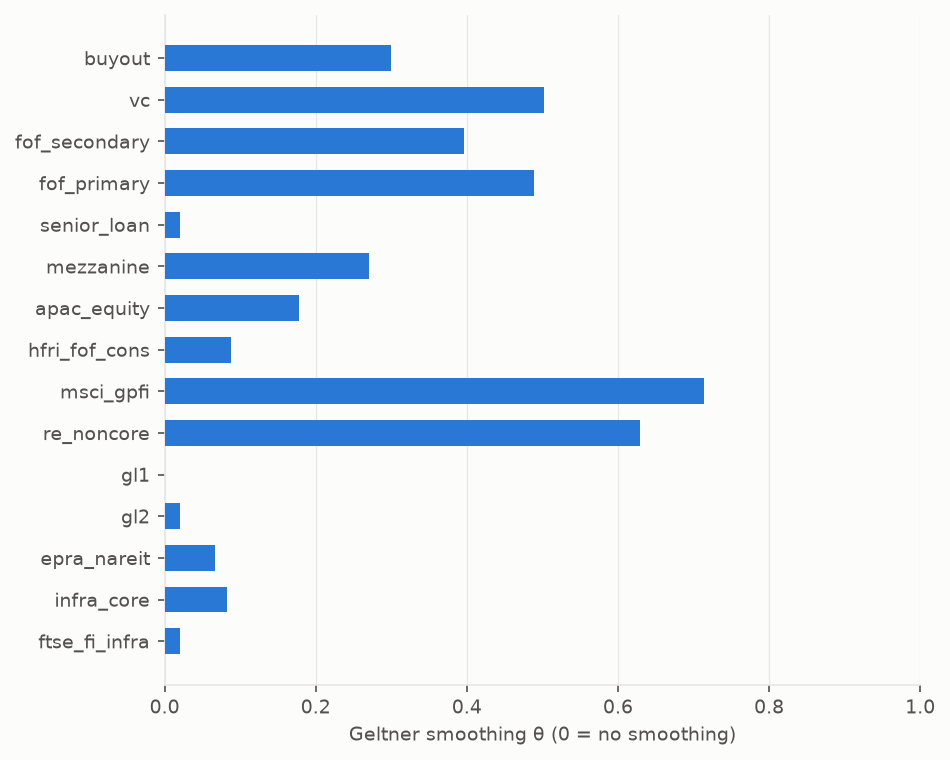

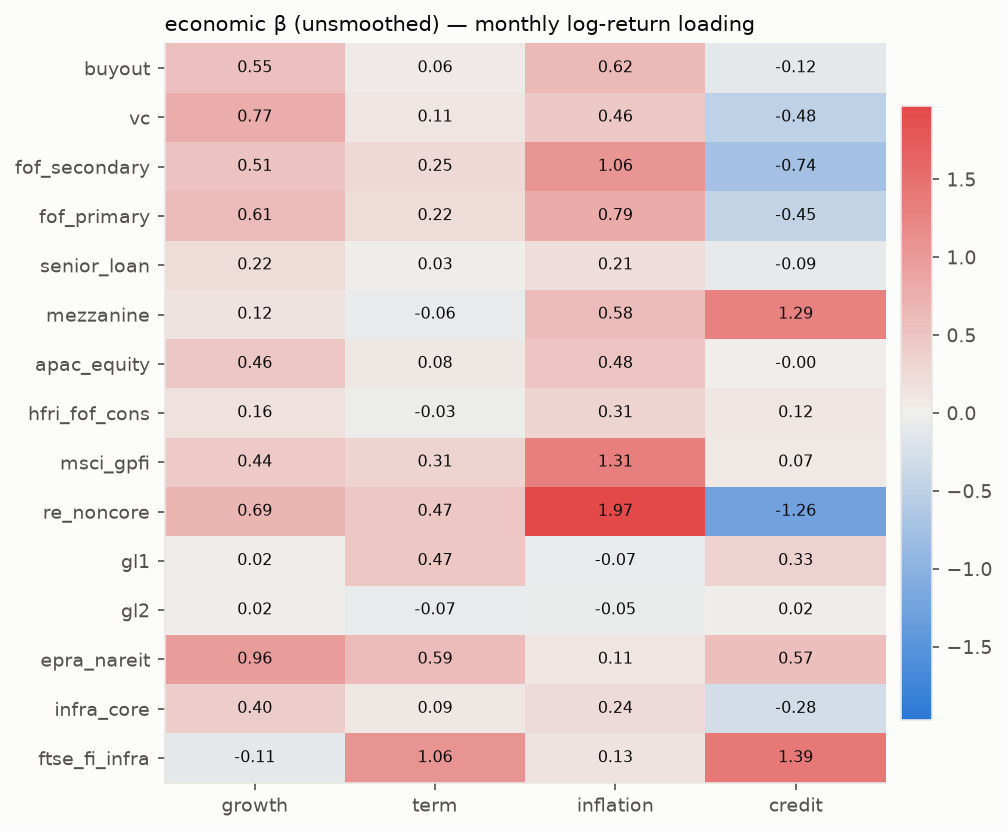

In [8]:
plots.plot_theta(pb, order, FIGS / "theta.png"); display(Image(FIGS / "theta.png"))
plots.plot_beta_heatmap(pb, order, factors, FIGS / "beta_economic.png"); display(Image(FIGS / "beta_economic.png"))

## 4. 최신 nowcast

각 시리즈의 마지막 보고 분기 이후: 팩터가 완전한 분기(complete) 와 진행 중 분기(partial(QTD): 관측된 QTD 팩터 + 남은 기간 표본평균). h ≥ 2 는 직전 nowcast 를 y_{q−1} 로 넣은 반복 예측.

In [9]:
now = pd.read_csv(PROC / "nowcast_latest.csv", parse_dates=["quarter", "last_reported"])
meta = json.loads((PROC / "nowcast_meta.json").read_text(encoding="utf-8"))
display(Markdown(f"팩터 기준일 **{meta['asof']}**, 진행 중 분기 {qlabel(meta['current_quarter_end'])} (경과 {meta['current_quarter_days']} 영업일). QTD 팩터: " + ", ".join(f"{k} {pct(v)}" for k, v in meta["qtd_factors"].items())))
t = now.assign(quarter=now.quarter.map(qlabel), last_reported=now.last_reported.map(qlabel)).drop(columns=["index"])
t.style.format({c: "{:.2%}" for c in ["ridge_dl", "ss_kalman", "ss_sd", "ensemble"]}).hide(axis="index")

팩터 기준일 **2026-09-15**, 진행 중 분기 2026Q3 (경과 55 영업일). QTD 팩터: growth 1.07%, term -2.93%, inflation 1.03%, credit -0.03%

code,group,quarter,last_reported,h,type,factor_days,ridge_dl,ss_kalman,ss_sd,ensemble
buyout,PE,2026Q2,2026Q1,1,complete,65,6.07%,7.00%,2.44%,6.54%
buyout,PE,2026Q3,2026Q1,2,partial(QTD),55,3.97%,4.42%,2.44%,4.19%
vc,PE,2026Q2,2026Q1,1,complete,65,7.22%,8.39%,3.61%,7.80%
vc,PE,2026Q3,2026Q1,2,partial(QTD),55,5.83%,5.74%,3.61%,5.78%
fof_secondary,PE,2026Q2,2026Q1,1,complete,65,4.69%,5.32%,2.76%,5.01%
fof_secondary,PE,2026Q3,2026Q1,2,partial(QTD),55,4.78%,3.91%,2.76%,4.34%
fof_primary,PE,2026Q2,2026Q1,1,complete,65,5.11%,5.42%,1.99%,5.26%
fof_primary,PE,2026Q3,2026Q1,2,partial(QTD),55,3.89%,3.80%,1.99%,3.84%
senior_loan,PE,2026Q2,2026Q1,1,complete,65,2.71%,4.43%,1.45%,3.57%
senior_loan,PE,2026Q3,2026Q1,2,partial(QTD),55,1.81%,1.84%,1.45%,1.83%


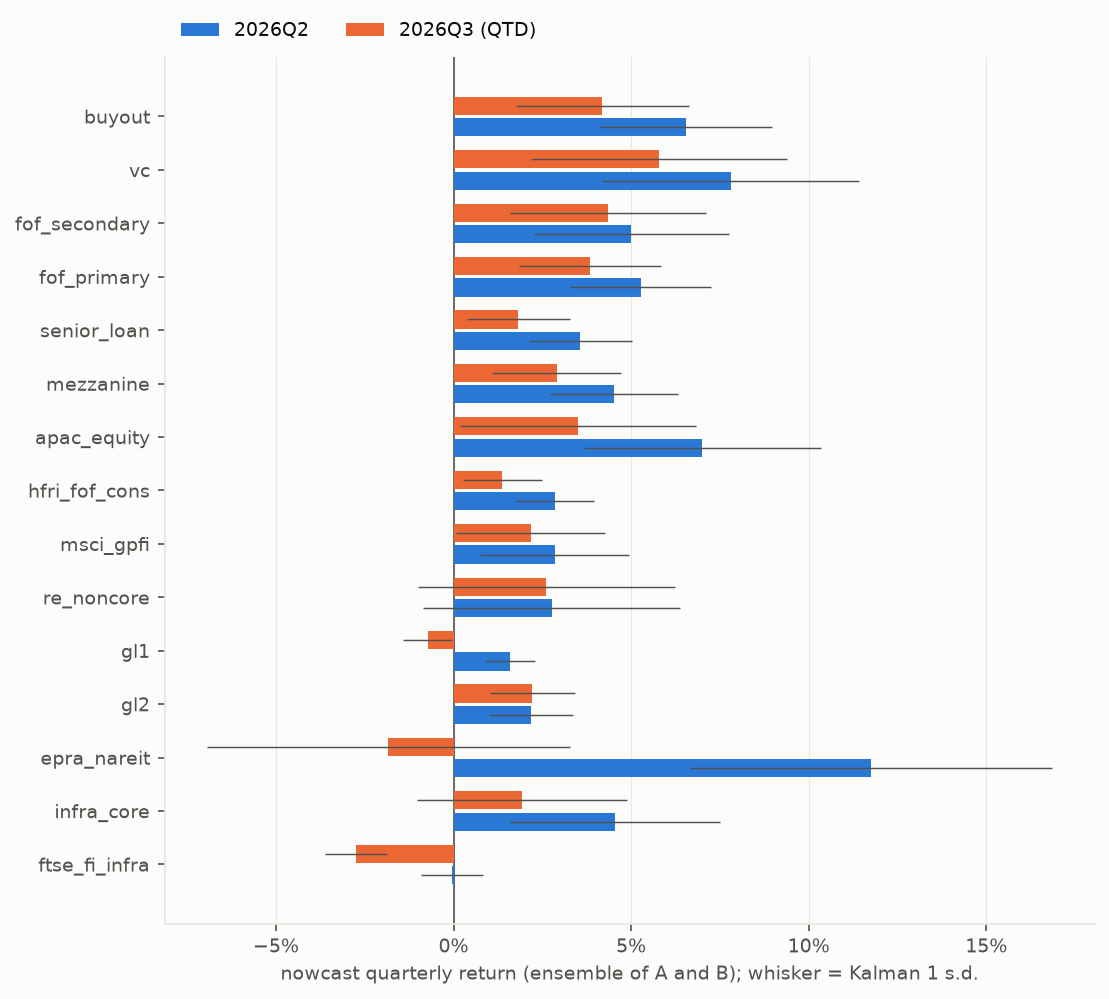

In [10]:
latest_q = sorted(now.quarter.unique())[-2:]
plots.plot_latest_nowcast(now, order, FIGS / "nowcast_latest.png", [pd.Timestamp(q) for q in latest_q]); display(Image(FIGS / "nowcast_latest.png"))

### 엑셀 21 라벨 기준 (Ensemble)

In [11]:
lab = pd.read_csv(PROC / "nowcast_by_label_ensemble.csv", index_col=0, parse_dates=True)
lab.index = lab.index.map(qlabel)
lab.T.style.format("{:.2%}", na_rep="")

quarter,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2,2026Q3
Buyout,,,,,,6.54%,4.19%
Growth,,,,,,7.80%,5.78%
Venture Capital,,,,,,7.80%,5.78%
Fund of Fund,,,,,,5.01%,4.34%
GP-Stake / Continuation Vehicle,,,,,,5.01%,4.34%
Long-term Core,,,,,,5.26%,3.84%
Senior Credit,,,,,,3.57%,1.83%
Junior Credit,,,,,,4.51%,2.90%
국내 사모투자,,,,,,7.01%,3.51%
Hedge Fund,,,,,,2.85%,1.38%


## 5. 읽는 법·주의

- **PE(Buyout·FoF·Mezz), HFRI, 상장 REIT, G-L 1, FTSE 인프라 채권**은 팩터 nowcast 가 AR(1)·평균을 크게 이긴다 (R²_OOS 0.5~0.9).
- **감정평가 부동산(Burgiss RE, MSCI GPFI, G-L 2)** 은 AR(1) 이 낫거나 비슷하다 — θ 가 0.6~0.7 로 보고 수익률의 자기상관이 지배적이고, 4개 팩터로는 부동산 고유 요인을 못 잡는다.
- Ensemble 은 대체로 두 모델 중 나은 쪽과 비슷하거나 낫다. 단일 모델을 고르기보다 평균을 쓰는 것이 안전하다.
- 의사 실시간(최종 빈티지, y_{q−1} 즉시 관측 가정) 이라 실전 정확도는 이보다 낮다. OOS 표본이 34~57분기로 짧아 DM 검정은 참고용.
- 팩터 데이터는 `macro_factor` 저장소의 산출물을 읽기만 한다. 팩터 정의·부호는 그 저장소의 `SPEC.md` 를 따른다 (term + = 금리 하락, inflation + = BEI 상승, credit + = 스프레드 축소).
